In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import *
import torch
import pandas as pd
from scipy.linalg import lu_factor, lu_solve
from sklearn.model_selection import train_test_split
from matplotlib.colors import LogNorm

# Plots: 

In [22]:
def plot_loss(loss_fct, w_1_range, w_2_range, alone='no'):
    w1 = np.linspace(w_1_range[0], w_1_range[1], 1000)
    w2 = np.linspace(w_2_range[0], w_2_range[1], 1000)
    W1, W2 = np.meshgrid(w1, w2)
    Loss = loss_fct([W1, W2])

    if alone == 'yes':
        plt.figure(figsize=(6, 5))

    plt.imshow(
        Loss,
        extent=[w1.min(), w1.max(), w2.min(), w2.max()],
        origin='lower',
        aspect='auto',
        cmap='RdBu', alpha=0.5, vmin=0, vmax=2
    
    )
    plt.colorbar(label='L(w1, w2)')
    plt.xlabel('w1')
    plt.ylabel('w2')
    plt.title('Heatmap af weightspace (loss landscape)')

def plot_brownian(BM): 
    plt.plot(BM[:, 0], BM[:, 1], c='black', linewidth=1, label='path')
    plt.scatter(BM[:, 0], BM[:, 1], s=5, c='red')
    plt.scatter(BM[0,0], BM[0,1], c='red', s=50, label="start")
    plt.scatter(BM[-1,0], BM[-1,1], c='white', edgecolor='black', s=50, label="end")
    plt.legend()

def plot_optimization_steps(mu_history):
    # path line
    #plt.plot(mu_history[:, 0], mu_history[:, 1],
     #        c='lightblue', linewidth=1, alpha=0.8)
    # intermediate points
    plt.scatter(mu_history[:, 0], mu_history[:, 1],
                s=15, c='lightblue', alpha=0.9)
    # start
    plt.scatter(mu_history[0, 0], mu_history[0, 1],
                s=100, c='cornflowerblue', edgecolor='black', label="start")
    # final μ
    plt.scatter(mu_history[-2, 0], mu_history[-2, 1],
                s=120, c='royalblue', edgecolor='black', label="final μ")
    plt.legend()

def plot_loss_opt(steps,loss):
    plt.plot(steps,loss)
    plt.xlabel('nr of step')
    plt.ylabel('loss')
    plt.title('loss over optimisation')


def plot_optimization_overview(loss_fct, w_1_range, w_2_range, mu_history, steps, loss):
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # ---- Left: Loss landscape + optimization path ----
    plt.sca(axes[0])  # set current axis
    plot_loss(loss_fct, w_1_range, w_2_range)
    plot_optimization_steps(mu_history)
    axes[0].set_title("Loss landscape with optimization of E[L] (no drift)")

    # ---- Right: Loss vs steps ----
    plt.sca(axes[1])
    plot_loss_opt(steps, loss)
    axes[1].set_title("Loss over optimization")

    plt.tight_layout()
    plt.show()

def Banan(theta):
    return np.exp(-(theta[0]*theta[1]-1)**2)



In [14]:
# vi laver her noice injection for at sikre, at metrikken bliver positivt definit


def L(theta):
    epsi = 1e-6
    return (theta[0]*theta[1]-1)**2 + epsi

def L_batch(theta):
    # theta: (N, 2)
    epsi = 1e-6
    return (theta[:, 0] * theta[:, 1] - 1.0) ** 2 + epsi

def grad_L(theta):
    t = theta[0] * theta[1] - 1.0
    return 2.0 * t * torch.stack([theta[1], theta[0]])

def Metric(theta, eps=1e-12):
    g = grad_L(theta)    
    I = torch.eye(len(g), dtype=g.dtype, device=g.device)
    sdot = torch.dot(g, g)

    if sdot.detach().item() < eps:
        return I
    
    LTL = torch.outer(g,g)
    
    return I + LTL

# def sqrt_M_inv(M):
#     evals, evecs = torch.linalg.eigh(M)
#     return (evecs * (1.0 / torch.sqrt(evals))) @ evecs.T

def sqrt_M_inv(theta, eps=1e-12):
    g = grad_L(theta)    
    I = torch.eye(len(g), dtype=g.dtype, device=g.device)
    s = torch.dot(g, g)
    # print(f"s={s}")
    if s.detach().item() < eps:
        return I

    coeff = 1.0 - 1.0 / torch.sqrt(1.0 + s)

    return I - coeff * torch.outer(g, g) / s


def compute_q(theta):
    M = Metric(theta)
    M_inv = torch.linalg.inv(M)
    M_det = torch.det(M)
    q = torch.sqrt(M_det) * M_inv
    return q, M_det



def compute_BM(start_point, step_size, walk_length, random_state=None):
    if random_state is not None:
        torch.manual_seed(random_state)
    
    theta = torch.tensor(start_point, dtype=torch.float32, requires_grad=True)
    path = [theta.clone()]
    losses = []

    dt = torch.tensor(step_size)
    sqrt_dt = torch.sqrt(dt)

    for _ in range(walk_length):
        M = Metric(theta)
        Minv_sqrt = sqrt_M_inv(theta, eps=1e-12)
        eps = torch.randn(2)

        #drift_term = compute_drift(theta)
        theta = theta + sqrt_dt * (Minv_sqrt @ eps)
        path.append(theta.detach().clone())

        losses.append(L(theta))
    
    return torch.stack(path)

def sample_q_endpoints(mu, n_samples, walk_len, step_size, detach_from_mu=False):
    samples = []
    dt = torch.tensor(step_size, dtype=mu.dtype, device=mu.device)
    sqrt_dt = torch.sqrt(dt)

    for _ in range(n_samples):
        if detach_from_mu:
            # detached from mu, but still differentiable wrt theta itself
            theta = mu.detach().clone().requires_grad_(True)
        else:
            # keep dependency on mu for optimizing mu
            theta = mu

        for _ in range(walk_len):
            M = Metric(theta)
            Minv_sqrt = sqrt_M_inv(theta, eps=1e-6)
            eps = torch.randn(2, dtype=mu.dtype, device=mu.device)
            theta = theta + sqrt_dt * (Minv_sqrt @ eps)

        # for discriminator training, no need to keep graph
        samples.append(theta.detach() if detach_from_mu else theta)

    return torch.stack(samples, dim=0)

def sample_prior(n_samples, dtype, device):
    return torch.randn(n_samples, 2, dtype=dtype, device=device)


In [5]:
def VI_Brownian(mu_start, learning_rate, num_updates, BM_step_size, BM_walk_len, n_sampels, eps=1e-6, seed=None ):
    if seed is not None:
        torch.manual_seed(seed)

    mu = torch.nn.Parameter(torch.tensor([mu_start[0], mu_start[1]], dtype=torch.float64))
    opt = torch.optim.Adam([mu], lr=learning_rate)

    mu_history = [mu.detach().cpu().numpy().copy()]
    loss_history = []

    for k in range(num_updates):
        
        end_points = sample_q_endpoints(mu, n_sampels, BM_walk_len, BM_step_size, detach_from_mu=False )
        loss_est = L_batch(end_points).mean()

        

        opt.zero_grad()
        loss_est.backward()
        opt.step()

        loss_history.append(loss_est.detach().cpu().item())
        mu_history.append(mu.detach().cpu().numpy().copy())



        if torch.isnan(loss_est) or torch.isinf(loss_est):
            print(f"Stopping early at iter {k+1}: loss is NaN/Inf")
            break

        if (k + 1) % 50 == 0:
            print(f"iter {k+1:4d} | loss_est={loss_est.item():.6f} | mu={mu.detach().cpu().numpy()}")

    return np.array(mu_history), np.array(loss_history)

In [6]:
mu_start = [2.0, 2.0]
learning_rate = 0.01
num_updates = 300
BM_step_size = 0.01
BM_walk_len = 50
n_sampels = 100
mu_path, loss = VI_Brownian(mu_start, learning_rate, num_updates, BM_step_size, BM_walk_len, n_sampels, eps=1e-6, seed=1)





iter   50 | loss_est=1.742137 | mu=[1.56777283 1.5676869 ]
iter  100 | loss_est=0.657274 | mu=[1.35470656 1.35471455]
iter  150 | loss_est=0.476144 | mu=[1.26721437 1.26831643]
iter  200 | loss_est=0.493702 | mu=[1.22019521 1.22101998]
iter  250 | loss_est=0.469097 | mu=[1.18589345 1.18743136]
iter  300 | loss_est=0.429191 | mu=[1.15926436 1.15906485]


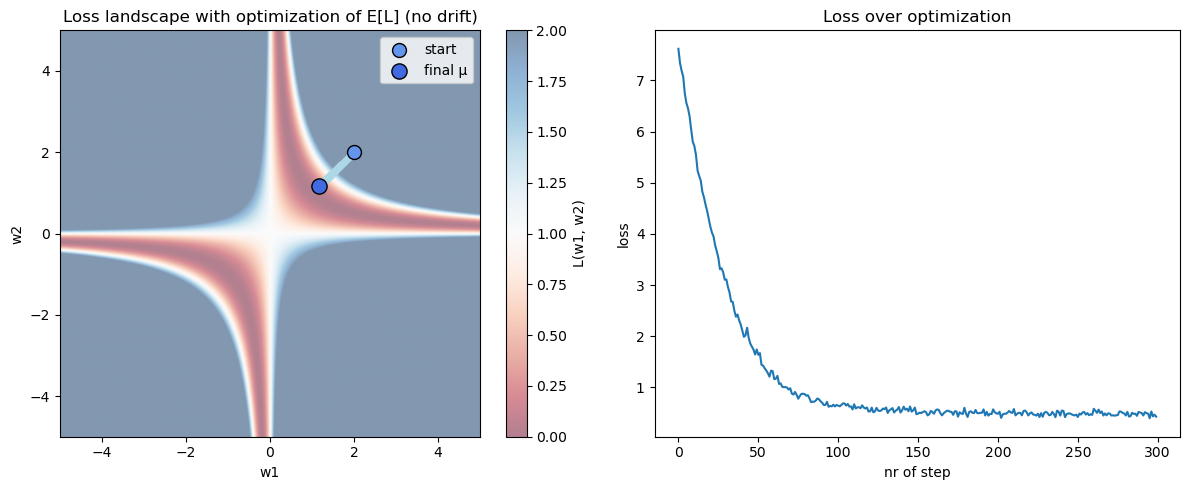

In [23]:
steps = range(len(loss))

plot_optimization_overview(L, [-5,5],[-5,5], mu_path, steps, loss)